# Classical ML Models Performance Comparison

Compare all trained classical machine learning models (SVM, k-NN, Decision Tree, Random Forest, Logistic Regression) on the test dataset.

In [1]:
%cd /content

# Remove any old repository copy
!rm -rf Bird-Species-Classification-ML

# Clone the Week 5 branch
!git clone -b madina-week5 --single-branch \
https://github.com/01329582993/Bird-Species-Classification-ML.git

# Enter the project folder
%cd /content/Bird-Species-Classification-ML

# Confirm the correct branch
!git branch --show-current

/content
Cloning into 'Bird-Species-Classification-ML'...
remote: Enumerating objects: 181, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 181 (delta 82), reused 53 (delta 33), pack-reused 71 (from 1)
Receiving objects: 100% (181/181), 5.08 MiB | 23.86 MiB/s, done.
Resolving deltas: 100% (112/112), done.
/content/Bird-Species-Classification-ML
madina-week5


In [2]:
from pathlib import Path

project_folder = Path(
    "/content/Bird-Species-Classification-ML"
)

# Search for saved feature files
npz_files = sorted(
    project_folder.rglob("*.npz")
)

pkl_files = sorted(
    project_folder.rglob("*.pkl")
)

print("NPZ feature files found:")
if npz_files:
    for file in npz_files:
        print("-", file)
else:
    print("No NPZ files found.")

print("\nPKL files found:")
if pkl_files:
    for file in pkl_files:
        print("-", file)
else:
    print("No PKL files found.")

NPZ feature files found:
No NPZ files found.

PKL files found:
No PKL files found.


In [3]:
from google.colab import files

uploaded = files.upload()

Saving combined_hog_color_lbp.npz to combined_hog_color_lbp.npz
Saving label_mapping.pkl to label_mapping.pkl


In [4]:
from pathlib import Path
import numpy as np
import joblib

# Search inside all Colab folders
combined_files = list(
    Path("/content").rglob("combined_hog_color_lbp*.npz")
)

mapping_files = list(
    Path("/content").rglob("label_mapping*.pkl")
)

if not combined_files:
    raise FileNotFoundError(
        "combined_hog_color_lbp.npz was not found."
    )

if not mapping_files:
    raise FileNotFoundError(
        "label_mapping.pkl was not found."
    )

# Use the newest uploaded copies
combined_file = max(
    combined_files,
    key=lambda path: path.stat().st_mtime
)

mapping_file = max(
    mapping_files,
    key=lambda path: path.stat().st_mtime
)

feature_data = np.load(
    combined_file,
    allow_pickle=True
)

label_mapping = joblib.load(mapping_file)

print("Using feature file:", combined_file)
print("Using mapping file:", mapping_file)
print("NPZ keys:", feature_data.files)
print("Number of classes:", len(label_mapping))

Using feature file: /content/Bird-Species-Classification-ML/combined_hog_color_lbp.npz
Using mapping file: /content/Bird-Species-Classification-ML/label_mapping.pkl
NPZ keys: ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']
Number of classes: 20


In [5]:
X_train_combined = feature_data["X_train"]
y_train = feature_data["y_train"]

X_val_combined = feature_data["X_val"]
y_val = feature_data["y_val"]

X_test_combined = feature_data["X_test"]
y_test = feature_data["y_test"]

print("Training:", X_train_combined.shape, y_train.shape)
print("Validation:", X_val_combined.shape, y_val.shape)
print("Testing:", X_test_combined.shape, y_test.shape)

Training: (780, 8206) (780,)
Validation: (167, 8206) (167,)
Testing: (168, 8206) (168,)


In [6]:
HOG_FEATURE_COUNT = 8100
COLOR_FEATURE_COUNT = 96
LBP_FEATURE_COUNT = 10

TOTAL_FEATURE_COUNT = (
    HOG_FEATURE_COUNT
    + COLOR_FEATURE_COUNT
    + LBP_FEATURE_COUNT
)

assert X_train_combined.shape[1] == TOTAL_FEATURE_COUNT
assert X_val_combined.shape[1] == TOTAL_FEATURE_COUNT
assert X_test_combined.shape[1] == TOTAL_FEATURE_COUNT

# HOG-only features
X_train_hog = X_train_combined[:, :HOG_FEATURE_COUNT]
X_val_hog = X_val_combined[:, :HOG_FEATURE_COUNT]
X_test_hog = X_test_combined[:, :HOG_FEATURE_COUNT]

# Color Histogram-only features
color_start = HOG_FEATURE_COUNT
color_end = HOG_FEATURE_COUNT + COLOR_FEATURE_COUNT

X_train_color = X_train_combined[:, color_start:color_end]
X_val_color = X_val_combined[:, color_start:color_end]
X_test_color = X_test_combined[:, color_start:color_end]

print("HOG feature shapes:")
print("Training:", X_train_hog.shape)
print("Validation:", X_val_hog.shape)
print("Testing:", X_test_hog.shape)

print("\nColor Histogram feature shapes:")
print("Training:", X_train_color.shape)
print("Validation:", X_val_color.shape)
print("Testing:", X_test_color.shape)

HOG feature shapes:
Training: (780, 8100)
Validation: (167, 8100)
Testing: (168, 8100)

Color Histogram feature shapes:
Training: (780, 96)
Validation: (167, 96)
Testing: (168, 96)


In [7]:
from sklearn.preprocessing import StandardScaler

# Scale HOG features
hog_scaler = StandardScaler()

X_train_hog_scaled = hog_scaler.fit_transform(
    X_train_hog
).astype("float32")

X_val_hog_scaled = hog_scaler.transform(
    X_val_hog
).astype("float32")

X_test_hog_scaled = hog_scaler.transform(
    X_test_hog
).astype("float32")


# Scale Color Histogram features
color_scaler = StandardScaler()

X_train_color_scaled = color_scaler.fit_transform(
    X_train_color
).astype("float32")

X_val_color_scaled = color_scaler.transform(
    X_val_color
).astype("float32")

X_test_color_scaled = color_scaler.transform(
    X_test_color
).astype("float32")


print("HOG features scaled:", X_train_hog_scaled.shape)
print("Color features scaled:", X_train_color_scaled.shape)

HOG features scaled: (780, 8100)
Color features scaled: (780, 96)


In [8]:
import pandas as pd

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = list(range(1, 32, 2))

comparison_results = []

for k in k_values:

    # HOG k-NN
    hog_knn = KNeighborsClassifier(
        n_neighbors=k,
        weights="uniform",
        metric="euclidean",
        n_jobs=-1
    )

    hog_knn.fit(
        X_train_hog_scaled,
        y_train
    )

    hog_predictions = hog_knn.predict(
        X_val_hog_scaled
    )

    hog_accuracy = accuracy_score(
        y_val,
        hog_predictions
    )


    # Color Histogram k-NN
    color_knn = KNeighborsClassifier(
        n_neighbors=k,
        weights="uniform",
        metric="euclidean",
        n_jobs=-1
    )

    color_knn.fit(
        X_train_color_scaled,
        y_train
    )

    color_predictions = color_knn.predict(
        X_val_color_scaled
    )

    color_accuracy = accuracy_score(
        y_val,
        color_predictions
    )


    comparison_results.append({
        "k": k,
        "HOG_accuracy": hog_accuracy,
        "Color_accuracy": color_accuracy
    })

    print(
        f"k={k:2d} | "
        f"HOG={hog_accuracy * 100:.2f}% | "
        f"Color={color_accuracy * 100:.2f}%"
    )

k= 1 | HOG=7.78% | Color=9.58%
k= 3 | HOG=7.78% | Color=7.78%
k= 5 | HOG=11.38% | Color=12.57%
k= 7 | HOG=11.98% | Color=11.98%
k= 9 | HOG=10.78% | Color=13.17%
k=11 | HOG=10.78% | Color=11.98%
k=13 | HOG=11.98% | Color=11.38%
k=15 | HOG=12.57% | Color=13.17%
k=17 | HOG=11.38% | Color=13.17%
k=19 | HOG=11.98% | Color=11.98%
k=21 | HOG=13.17% | Color=13.17%
k=23 | HOG=11.98% | Color=13.77%
k=25 | HOG=13.17% | Color=13.17%
k=27 | HOG=13.77% | Color=13.17%
k=29 | HOG=11.98% | Color=14.37%
k=31 | HOG=14.97% | Color=14.37%


In [9]:
comparison_table = pd.DataFrame(
    comparison_results
)

comparison_table["HOG_percentage"] = (
    comparison_table["HOG_accuracy"] * 100
)

comparison_table["Color_percentage"] = (
    comparison_table["Color_accuracy"] * 100
)

display(comparison_table)

,k,HOG_accuracy,Color_accuracy,HOG_percentage,Color_percentage
0,1,0.077844,0.095808,7.784431,9.580838
1,3,0.077844,0.077844,7.784431,7.784431
2,5,0.113772,0.125749,11.377246,12.574850
3,7,0.119760,0.119760,11.976048,11.976048
4,9,0.107784,0.131737,10.778443,13.173653
5,11,0.107784,0.119760,10.778443,11.976048
6,13,0.119760,0.113772,11.976048,11.377246
7,15,0.125749,0.131737,12.574850,13.173653
8,17,0.113772,0.131737,11.377246,13.173653
9,19,0.119760,0.119760,11.976048,11.976048


In [10]:
# Find the best HOG result
best_hog_index = comparison_table[
    "HOG_accuracy"
].idxmax()

best_hog_k = int(
    comparison_table.loc[
        best_hog_index,
        "k"
    ]
)

best_hog_accuracy = float(
    comparison_table.loc[
        best_hog_index,
        "HOG_accuracy"
    ]
)


# Find the best Color Histogram result
best_color_index = comparison_table[
    "Color_accuracy"
].idxmax()

best_color_k = int(
    comparison_table.loc[
        best_color_index,
        "k"
    ]
)

best_color_accuracy = float(
    comparison_table.loc[
        best_color_index,
        "Color_accuracy"
    ]
)


print("Best HOG k:", best_hog_k)
print(
    f"Best HOG validation accuracy: "
    f"{best_hog_accuracy * 100:.2f}%"
)

print("\nBest Color Histogram k:", best_color_k)
print(
    f"Best Color Histogram validation accuracy: "
    f"{best_color_accuracy * 100:.2f}%"
)

Best HOG k: 31
Best HOG validation accuracy: 14.97%

Best Color Histogram k: 29
Best Color Histogram validation accuracy: 14.37%


In [11]:
final_comparison_table = pd.DataFrame({
    "Feature Type": [
        "HOG",
        "Color Histogram"
    ],
    "Best k": [
        best_hog_k,
        best_color_k
    ],
    "Validation Accuracy": [
        best_hog_accuracy,
        best_color_accuracy
    ],
    "Validation Percentage": [
        best_hog_accuracy * 100,
        best_color_accuracy * 100
    ]
})

display(final_comparison_table)

,Feature Type,Best k,Validation Accuracy,Validation Percentage
0,HOG,31,0.149701,14.970060
1,Color Histogram,29,0.143713,14.371257


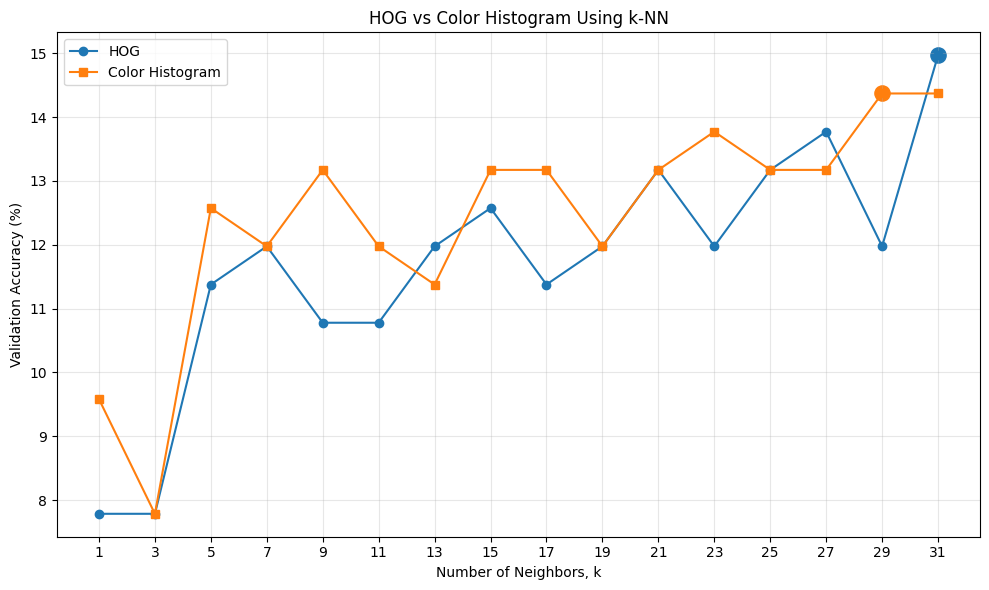

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    comparison_table["k"],
    comparison_table["HOG_percentage"],
    marker="o",
    label="HOG"
)

plt.plot(
    comparison_table["k"],
    comparison_table["Color_percentage"],
    marker="s",
    label="Color Histogram"
)

plt.scatter(
    best_hog_k,
    best_hog_accuracy * 100,
    s=120
)

plt.scatter(
    best_color_k,
    best_color_accuracy * 100,
    s=120
)

plt.xlabel("Number of Neighbors, k")
plt.ylabel("Validation Accuracy (%)")
plt.title("HOG vs Color Histogram Using k-NN")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

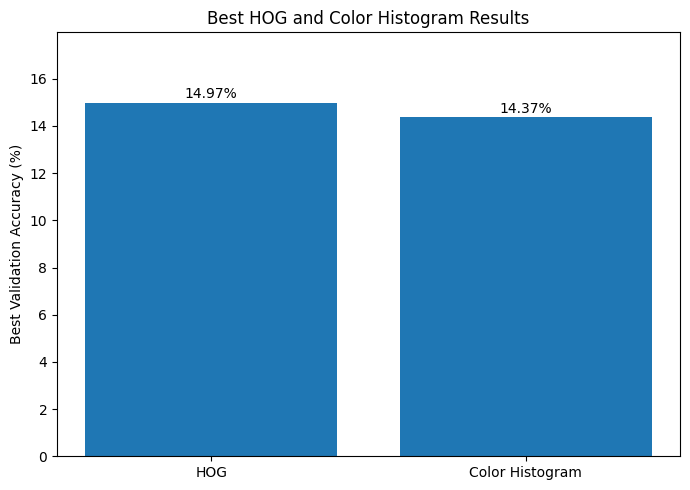

In [13]:
plt.figure(figsize=(7, 5))

plt.bar(
    final_comparison_table["Feature Type"],
    final_comparison_table["Validation Percentage"]
)

plt.ylabel("Best Validation Accuracy (%)")
plt.title("Best HOG and Color Histogram Results")

for index, value in enumerate(
    final_comparison_table["Validation Percentage"]
):
    plt.text(
        index,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(
    0,
    max(
        final_comparison_table[
            "Validation Percentage"
        ]
    ) + 3
)

plt.tight_layout()
plt.show()

### HOG vs Color Histogram Conclusion

HOG and Color Histogram features were compared using the same k-NN classifier, training set, validation set, scaling method and odd k values from 1 to 31.

HOG achieved its highest validation accuracy of 14.97% using k = 31. Color Histogram achieved its highest validation accuracy of 14.37% using k = 29. Therefore, HOG performed slightly better than Color Histogram for this experiment.

In [ ]:
# Load pre-computed features and labels
# If features are missing, automatically download the dataset and run extraction
import os
import sys
import shutil
import numpy as np
import joblib
from pathlib import Path

DATA_DIR = Path("./processed_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
npz_file = DATA_DIR / "combined_hog_color_lbp.npz"

if not npz_file.exists():
    print("Feature files not found. Running automatic feature extraction pipeline...")
    import pandas as pd
    import kagglehub
    from tqdm.auto import tqdm
    from PIL import Image
    from skimage.feature import hog, local_binary_pattern

    # ---- Step 1: Download and prepare dataset ----
    def locate_metadata():
        for p in [Path("metadata_preprocessed.csv"), DATA_DIR / "metadata_preprocessed.csv"]:
            if p.exists():
                return p
        return None

    metadata_file = locate_metadata()
    dataset_preprocessed_dir = Path("dataset_20_species_preprocessed")

    if metadata_file is None or not dataset_preprocessed_dir.exists():
        print("  Downloading CUB-200-2011 dataset via Kaggle Hub...")
        download_path = Path(kagglehub.dataset_download("wenewone/cub2002011"))
        DATASET_ROOT = download_path / "CUB_200_2011"
        IMAGES_FOLDER = DATASET_ROOT / "images"

        SUBSET_DIR = Path("./dataset_20_species")
        if SUBSET_DIR.exists():
            shutil.rmtree(SUBSET_DIR)
        SUBSET_DIR.mkdir(parents=True, exist_ok=True)

        bd_keywords = [
            'Crow', 'Kingfisher', 'Hummingbird', 'Mallard', 'Warbler',
            'Towhee', 'Jay', 'Creeper', 'Waxwing', 'Cuckoo',
            'Thrush', 'Woodpecker', 'Wren', 'Vireo', 'Catbird',
            'Meadowlark', 'Blackbird', 'Gull', 'Tern', 'Pelican'
        ]
        species_folders = sorted([f for f in IMAGES_FOLDER.iterdir() if f.is_dir()])
        selected_species = []
        for folder in species_folders:
            if any(kw.lower() in folder.name.lower() for kw in bd_keywords):
                if folder not in selected_species:
                    selected_species.append(folder)
            if len(selected_species) == 20:
                break

        for species_path in selected_species:
            shutil.copytree(str(species_path), SUBSET_DIR / species_path.name)

        classes_df = pd.read_csv(DATASET_ROOT / "classes.txt", sep=r"\s+", names=["class_id", "class_name"])
        images_df = pd.read_csv(DATASET_ROOT / "images.txt", sep=r"\s+", names=["image_id", "image_path"])
        labels_df = pd.read_csv(DATASET_ROOT / "image_class_labels.txt", sep=r"\s+", names=["image_id", "class_id"])

        selected_names = [p.name for p in selected_species]
        dataset_info = images_df.merge(labels_df, on="image_id").merge(classes_df, on="class_id")
        dataset_info = dataset_info[dataset_info["class_name"].isin(selected_names)].copy().reset_index(drop=True)
        dataset_info["full_image_path"] = dataset_info["image_path"].apply(lambda p: SUBSET_DIR / p)

        sys.path.append(str(Path(".").resolve()))
        from src.preprocessing import create_stratified_splits, preprocess_and_save_image

        split_metadata = create_stratified_splits(dataset_info, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_state=42)

        if dataset_preprocessed_dir.exists():
            shutil.rmtree(dataset_preprocessed_dir)
        dataset_preprocessed_dir.mkdir(parents=True, exist_ok=True)

        preprocessed_paths = []
        for idx, row in split_metadata.iterrows():
            dst_file = dataset_preprocessed_dir / Path(row["image_path"])
            preprocess_and_save_image(row["full_image_path"], dst_file, target_size=(224, 224))
            preprocessed_paths.append(str(dst_file))
        split_metadata["preprocessed_image_path"] = preprocessed_paths
        cols = ["image_id", "image_path", "class_id", "class_name", "split", "preprocessed_image_path"]
        split_metadata[cols].to_csv("metadata_preprocessed.csv", index=False)
        split_metadata[cols].to_csv(DATA_DIR / "metadata_preprocessed.csv", index=False)
        metadata_file = Path("metadata_preprocessed.csv")
        print("  Dataset preparation complete!")

    # ---- Step 2: Extract features ----
    def _extract_hog(img_path):
        img = Image.open(img_path).convert("L").resize((128, 128), Image.Resampling.LANCZOS)
        return hog(np.array(img), orientations=9, pixels_per_cell=(8,8),
                   cells_per_block=(2,2), block_norm='L2-Hys', visualize=False).astype(np.float32)

    def _extract_color(img_path):
        img_arr = np.array(Image.open(img_path).convert("RGB"))
        hists = []
        for ch in range(3):
            h, _ = np.histogram(img_arr[:,:,ch], bins=32, range=(0,256))
            h = h.astype(np.float32); h /= (h.sum() + 1e-9)
            hists.append(h)
        return np.concatenate(hists)

    def _extract_lbp(img_path):
        img_arr = np.array(Image.open(img_path).convert("L"), dtype=np.uint8)
        lbp = local_binary_pattern(img_arr, P=8, R=1, method="uniform")
        h, _ = np.histogram(lbp.ravel(), bins=np.arange(0,11), range=(0,10))
        h = h.astype(np.float32); h /= (h.sum() + 1e-9)
        return h

    metadata_df = pd.read_csv(locate_metadata())
    X_hog, X_color, X_lbp, y_all, splits_all = [], [], [], [], []

    print("  Extracting HOG + Color Histogram + LBP features...")
    for _, row in tqdm(metadata_df.iterrows(), total=len(metadata_df)):
        img_path = Path(row["preprocessed_image_path"])
        X_hog.append(_extract_hog(img_path))
        X_color.append(_extract_color(img_path))
        X_lbp.append(_extract_lbp(img_path))
        y_all.append(row["class_id"] - 1)
        splits_all.append(row["split"])

    X_hog = np.array(X_hog, dtype=np.float32)
    X_color = np.array(X_color, dtype=np.float32)
    X_lbp = np.array(X_lbp, dtype=np.float32)
    y_all = np.array(y_all, dtype=np.int32)
    splits_all = np.array(splits_all)
    X_all = np.concatenate([X_hog, X_color, X_lbp], axis=1)

    unique_classes = sorted(metadata_df["class_name"].unique())
    lm = {cls: idx for idx, cls in enumerate(unique_classes)}
    joblib.dump(lm, DATA_DIR / "label_mapping.pkl")

    for mask_name, mask in [("train", splits_all=="train"), ("val", splits_all=="val"), ("test", splits_all=="test")]:
        pass  # just to define masks for npz

    np.savez_compressed(
        npz_file,
        X_train=X_all[splits_all=="train"], y_train=y_all[splits_all=="train"],
        X_val=X_all[splits_all=="val"],   y_val=y_all[splits_all=="val"],
        X_test=X_all[splits_all=="test"],  y_test=y_all[splits_all=="test"]
    )
    print("  Feature extraction and save complete!")

# ---- Load the features ----
data = np.load(npz_file)
X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]

label_mapping = joblib.load(DATA_DIR / "label_mapping.pkl")
class_names = [k.split('.')[-1].replace('_', ' ') for k in sorted(label_mapping, key=label_mapping.get)]

print(f"Loaded feature dataset: {npz_file.name}")
print(f"  Training set  : {X_train.shape}")
print(f"  Validation set: {X_val.shape}")
print(f"  Testing set   : {X_test.shape}")
print(f"  Classes ({len(class_names)}): {class_names[:5]}...")

## 1. Load All Trained Models

In [ ]:
import joblib
from pathlib import Path

MODELS_DIR = Path("./models")
models = {}

model_files = {
    "SVM": "svm_model.pkl",
    "k-NN": "knn_model.pkl",
    "Decision Tree": "decision_tree_model.pkl",
    "Random Forest": "random_forest_model.pkl",
    "Logistic Regression": "logistic_regression_model.pkl"
}

for model_name, filename in model_files.items():
    path = MODELS_DIR / filename
    if path.exists():
        models[model_name] = joblib.load(path)
        print(f"Loaded model: {model_name}")
    else:
        print(f"[Warning] Model file missing: {filename}")

print(f"\nTotal loaded models for evaluation: {len(models)}")

## 2. Evaluate All Models & Build Leaderboard

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics_list = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    metrics_list.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision (%)": round(prec * 100, 2),
        "Recall (%)": round(rec * 100, 2),
        "F1-Score (%)": round(f1 * 100, 2)
    })

leaderboard_df = pd.DataFrame(metrics_list).sort_values("Accuracy (%)", ascending=False).reset_index(drop=True)
print("=== CLASSICAL ML MODEL LEADERBOARD ===")
display(leaderboard_df)

## 3. Visualize Model Performance Comparison

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Model", y="Accuracy (%)", data=leaderboard_df, palette="viridis")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 5),
                textcoords='offset points')

plt.title("Bird Species Classification - Model Test Accuracy Comparison", fontsize=14)
plt.ylim(0, 100)
plt.ylabel("Test Accuracy (%)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()